# 07 - short cluster guard grid

Test the proposed market-wide short cluster guard across a small parameter grid. The guard removes synchronized new short clusters when the market core has already fallen over the prior 24h. Goal: reduce December-like crash/rebound losses without destroying the champion's broad PnL profile.

In [1]:
import json
import tempfile
from pathlib import Path
import sys; sys.path.insert(0, ".")
from _lab import *

best = json.loads(BEST_JSON.read_text(encoding="utf-8"))
symbols = list(best["symbols"])
params = dict(best["params"])
tf = best["tf"]
start, end = best["period"]
initial_cash = 1000.0
base_code = BEST_STRATEGY_FILE.read_text(encoding="utf-8")

print("symbols:", symbols)
print("period:", start, "->", end)

symbols: ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']
period: 2024-01-01 -> 2026-01-01


In [2]:
cluster_append = r'''

_base_generate_signals = generate_signals

def generate_signals(data: dict[str, pd.DataFrame], params: dict) -> pd.DataFrame:
    signals = _base_generate_signals(data, params)
    if signals.empty:
        return signals
    min_cluster = int(params.get("short_cluster_min", 2))
    prior_threshold = float(params.get("short_cluster_prior_move", -0.045))
    core_symbols = params.get("short_cluster_core", None)
    s = signals.copy()
    s["timestamp"] = pd.to_datetime(s["timestamp"], utc=True)
    wide = s.pivot_table(index="timestamp", columns="symbol", values="position", aggfunc="last").sort_index().ffill().fillna(0.0)
    prior = {}
    for sym, df in data.items():
        prior[sym] = df["close"].astype(float).pct_change(6).reindex(wide.index)
    prior = pd.DataFrame(prior).reindex(columns=wide.columns)
    prev = wide.shift(1).fillna(0.0)
    short_entries = (wide < 0) & (prev >= 0)
    eval_cols = [c for c in wide.columns if core_symbols is None or c in set(core_symbols)]
    for ts in wide.index[short_entries[eval_cols].sum(axis=1) >= min_cluster]:
        syms = list(short_entries.columns[short_entries.loc[ts]])
        core_syms = [s for s in syms if s in eval_cols]
        if len(core_syms) < min_cluster:
            continue
        mean_prior = float(prior.loc[ts, core_syms].mean())
        if not np.isfinite(mean_prior) or mean_prior > prior_threshold:
            continue
        for sym in syms:
            idx = wide.index.get_loc(ts)
            j = idx
            col = wide.columns.get_loc(sym)
            while j < len(wide.index) and wide.iat[j, col] < 0:
                wide.iat[j, col] = 0.0
                j += 1
    out = wide.reset_index().melt(id_vars="timestamp", var_name="symbol", value_name="position")
    return out
'''
cluster_code = base_code + cluster_append

def run_code_variant(name, code, params_override=None):
    tmp = tempfile.TemporaryDirectory(prefix=f"vwb_{name}_")
    path = Path(tmp.name)
    (path / "strategy.py").write_text(code, encoding="utf-8")
    p = dict(params)
    if params_override:
        p.update(params_override)
    res = run_strategy_file(path / "strategy.py", symbols, start, end, params=p, tf=tf, return_curves=True)
    res["_tmp"] = tmp
    res["_name"] = name
    res["_params_override"] = params_override or {}
    return res

def summarize(name, res):
    curves = res["curves"]
    eq = rebase(curves["equity"], initial_cash)
    dec_start = pd.Timestamp("2025-12-01", tz="UTC")
    dec_end = pd.Timestamp("2026-01-01", tz="UTC")
    eq_dec = eq[(eq.index >= dec_start) & (eq.index < dec_end)]
    tr = curves["trades"].copy()
    tr["entry_time"] = pd.to_datetime(tr["entry_time"], utc=True)
    dec = tr[(tr["entry_time"] >= dec_start) & (tr["entry_time"] < dec_end)]
    return {
        "variant": name,
        **res.get("_params_override", {}),
        "end_equity": float(eq.iloc[-1]),
        "total_return": float(eq.iloc[-1] / eq.iloc[0] - 1),
        "max_dd": float(drawdown(eq).min()),
        "train_sharpe": res["main"]["train"].get("sharpe"),
        "oos_sharpe": res["main"]["oos"].get("sharpe"),
        "oos_return": res["main"]["oos"].get("total_return"),
        "oos_pf": res["main"]["oos"].get("profit_factor"),
        "n_trades": int(len(tr)),
        "dec_pnl": float(dec["pnl_quote"].sum()) if len(dec) else 0.0,
        "dec_trades": int(len(dec)),
        "dec_return": float(eq_dec.iloc[-1] / eq_dec.iloc[0] - 1) if len(eq_dec) > 1 else np.nan,
        "dec_max_dd": float(drawdown(eq_dec).min()) if len(eq_dec) > 1 else np.nan,
    }

In [3]:
results = {}
print("running champion")
results["champion"] = run_code_variant("champion", base_code, {})

grid = []
for min_cluster in [2, 3]:
    for threshold in [-0.035, -0.045, -0.055, -0.065]:
        grid.append({
            "short_cluster_min": min_cluster,
            "short_cluster_prior_move": threshold,
            "short_cluster_core": symbols,
        })

for g in grid:
    name = f"cluster_m{g['short_cluster_min']}_{abs(g['short_cluster_prior_move']):.3f}"
    print("running", name, g)
    results[name] = run_code_variant(name, cluster_code, g)
print("done")

running champion


running cluster_m2_0.035 {'short_cluster_min': 2, 'short_cluster_prior_move': -0.035, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m2_0.045 {'short_cluster_min': 2, 'short_cluster_prior_move': -0.045, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m2_0.055 {'short_cluster_min': 2, 'short_cluster_prior_move': -0.055, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m2_0.065 {'short_cluster_min': 2, 'short_cluster_prior_move': -0.065, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m3_0.035 {'short_cluster_min': 3, 'short_cluster_prior_move': -0.035, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m3_0.045 {'short_cluster_min': 3, 'short_cluster_prior_move': -0.045, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m3_0.055 {'short_cluster_min': 3, 'short_cluster_prior_move': -0.055, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


running cluster_m3_0.065 {'short_cluster_min': 3, 'short_cluster_prior_move': -0.065, 'short_cluster_core': ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'AVAXUSDT']}


done


In [4]:
summary = pd.DataFrame([summarize(name, res) for name, res in results.items()]).set_index("variant")
summary.sort_values(["dec_pnl", "end_equity"], ascending=False)

,end_equity,total_return,max_dd,train_sharpe,oos_sharpe,oos_return,oos_pf,n_trades,dec_pnl,dec_trades,dec_return,dec_max_dd,short_cluster_min,short_cluster_prior_move,short_cluster_core
variant,,,,,,,,,,,,,,,
cluster_m2_0.045,1888.869447,0.888869,-0.087204,2.123480,0.636343,0.051680,1.115047,454,-511.676517,22,-0.026796,-0.067896,2.0,-0.045,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m2_0.055,2026.530144,1.026530,-0.100304,2.292984,0.470011,0.039413,1.078536,482,-548.629711,22,-0.026780,-0.067857,2.0,-0.055,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m3_0.055,2110.514619,1.110515,-0.100281,2.380422,0.376607,0.029945,1.056940,500,-571.194640,22,-0.026772,-0.067838,3.0,-0.055,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m3_0.045,2113.232065,1.113232,-0.100273,2.430799,0.376599,0.029942,1.056940,494,-571.885202,22,-0.026770,-0.067833,3.0,-0.045,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m2_0.035,1569.791150,0.569791,-0.087346,1.635207,0.402877,0.027492,1.065671,427,-733.010667,19,-0.045096,-0.073989,2.0,-0.035,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m3_0.035,1704.622657,0.704623,-0.100483,1.858353,0.195674,0.010749,1.021417,477,-794.596438,19,-0.045021,-0.073871,3.0,-0.035,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m2_0.065,1960.293225,0.960293,-0.114744,2.177740,0.326829,0.025797,1.043539,505,-1752.886840,25,-0.082508,-0.100264,2.0,-0.065,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
cluster_m3_0.065,2005.611242,1.005611,-0.114747,2.256844,0.240970,0.015724,1.026165,513,-1793.478772,25,-0.082511,-0.100267,3.0,-0.065,"[BTCUSDT, ETHUSDT, SOLUSDT, AVAXUSDT]"
champion,2039.424881,1.039425,-0.114798,2.256844,0.376976,0.032848,1.054225,516,-1824.621128,25,-0.082548,-0.100312,NaN,NaN,NaN


In [5]:
# A simple compromise score: preserve ending equity, improve drawdown, and penalize December damage.
champ = summary.loc["champion"]
ranked = summary.copy()
ranked["equity_retention"] = ranked["end_equity"] / champ["end_equity"]
ranked["dd_improvement"] = champ["max_dd"] - ranked["max_dd"]
ranked["dec_pnl_improvement"] = ranked["dec_pnl"] - champ["dec_pnl"]
ranked["compromise_score"] = (
    ranked["equity_retention"]
    + 4.0 * ranked["dd_improvement"]
    + ranked["dec_pnl_improvement"] / abs(champ["dec_pnl"])
)
ranked.sort_values("compromise_score", ascending=False)[[
    "short_cluster_min", "short_cluster_prior_move", "end_equity", "equity_retention",
    "max_dd", "oos_sharpe", "oos_return", "oos_pf", "dec_pnl", "dec_max_dd", "n_trades", "compromise_score"
]]

,short_cluster_min,short_cluster_prior_move,end_equity,equity_retention,max_dd,oos_sharpe,oos_return,oos_pf,dec_pnl,dec_max_dd,n_trades,compromise_score
variant,,,,,,,,,,,,
cluster_m3_0.045,3.0,-0.045,2113.232065,1.036190,-0.100273,0.376599,0.029942,1.056940,-571.885202,-0.067833,494,1.664664
cluster_m3_0.055,3.0,-0.055,2110.514619,1.034858,-0.100281,0.376607,0.029945,1.056940,-571.194640,-0.067838,500,1.663741
cluster_m2_0.055,2.0,-0.055,2026.530144,0.993677,-0.100304,0.470011,0.039413,1.078536,-548.629711,-0.067857,482,1.635021
cluster_m2_0.045,2.0,-0.045,1888.869447,0.926178,-0.087204,0.636343,0.051680,1.115047,-511.676517,-0.067896,454,1.535373
cluster_m3_0.035,3.0,-0.035,1704.622657,0.835835,-0.100483,0.195674,0.010749,1.021417,-794.596438,-0.073871,477,1.343088
cluster_m2_0.035,2.0,-0.035,1569.791150,0.769722,-0.087346,0.402877,0.027492,1.065671,-733.010667,-0.073989,427,1.258182
cluster_m2_0.065,2.0,-0.065,1960.293225,0.961199,-0.114744,0.326829,0.025797,1.043539,-1752.886840,-0.100264,505,1.000296
cluster_m3_0.065,3.0,-0.065,2005.611242,0.983420,-0.114747,0.240970,0.015724,1.026165,-1793.478772,-0.100267,513,1.000286
champion,NaN,NaN,2039.424881,1.000000,-0.114798,0.376976,0.032848,1.054225,-1824.621128,-0.100312,516,1.000000


[saved] notebooks\volume_weighted_breakout\_out\07_cluster_guard_grid_full_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/07_cluster_guard_grid_full_equity_drawdown.png')

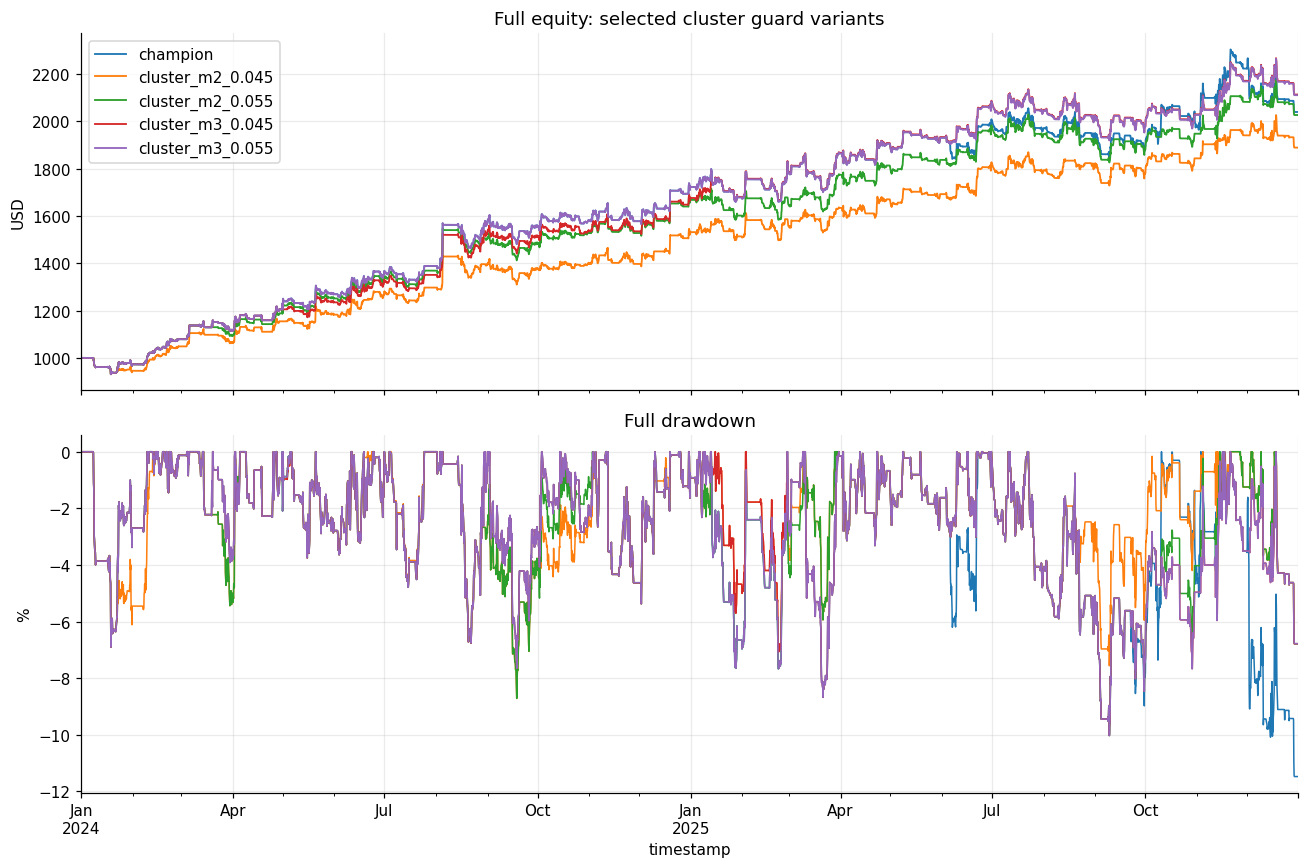

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, res in results.items():
    if name == "champion" or name in ["cluster_m2_0.045", "cluster_m2_0.055", "cluster_m3_0.045", "cluster_m3_0.055"]:
        eq = rebase(res["curves"]["equity"], initial_cash)
        eq.plot(ax=ax[0], label=name, lw=1.2)
        (drawdown(eq) * 100).plot(ax=ax[1], label=name, lw=1.0)
ax[0].set_title("Full equity: selected cluster guard variants")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")
ax[1].set_title("Full drawdown")
ax[1].set_ylabel("%")
show("07_cluster_guard_grid_full_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\07_cluster_guard_grid_december_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/07_cluster_guard_grid_december_equity_drawdown.png')

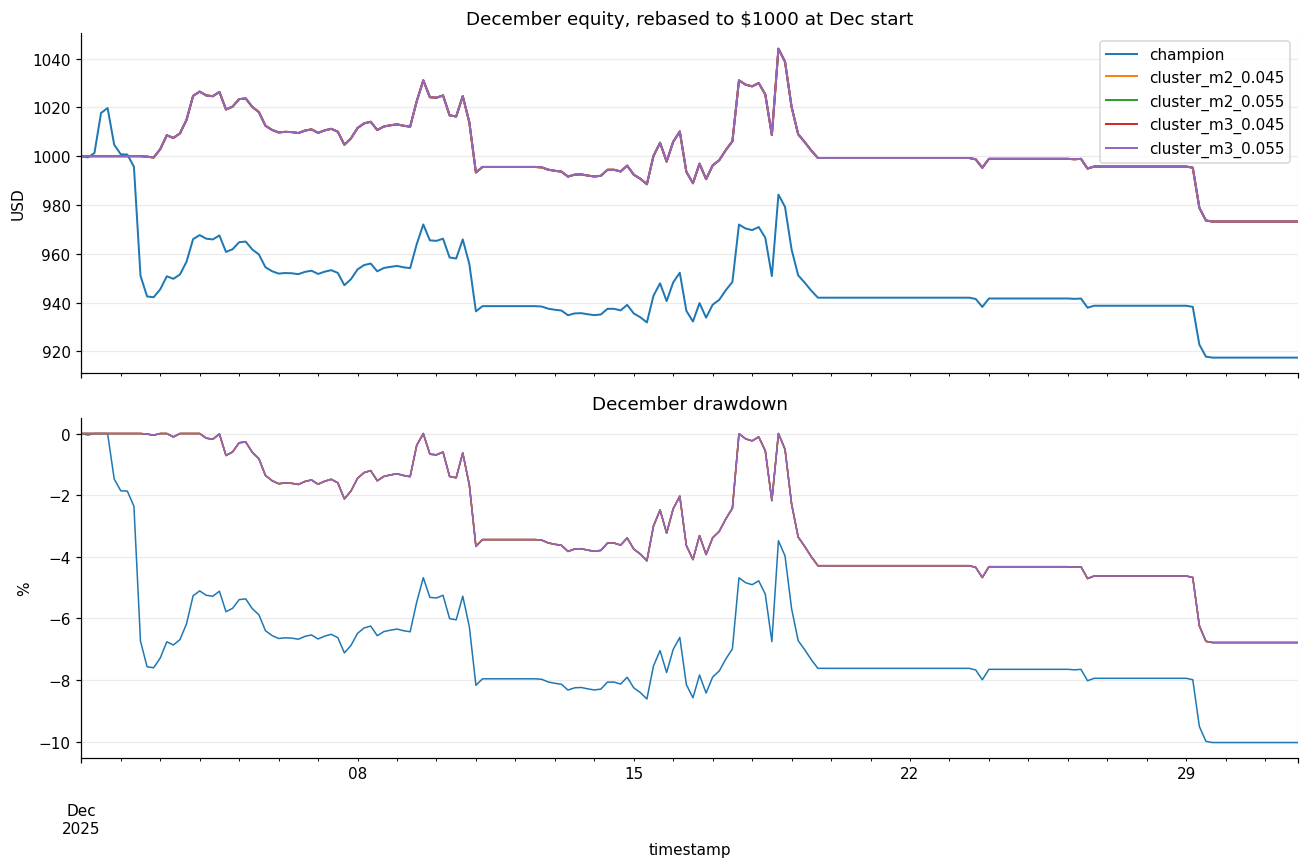

In [7]:
dec_start = pd.Timestamp("2025-12-01", tz="UTC")
dec_end = pd.Timestamp("2026-01-01", tz="UTC")
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for name, res in results.items():
    if name == "champion" or name in ["cluster_m2_0.045", "cluster_m2_0.055", "cluster_m3_0.045", "cluster_m3_0.055"]:
        eq = rebase(res["curves"]["equity"], initial_cash)
        eq_dec = eq[(eq.index >= dec_start) & (eq.index < dec_end)]
        (eq_dec / eq_dec.iloc[0] * 1000).plot(ax=ax[0], label=name, lw=1.3)
        (drawdown(eq_dec) * 100).plot(ax=ax[1], label=name, lw=1.0)
ax[0].set_title("December equity, rebased to $1000 at Dec start")
ax[0].set_ylabel("USD")
ax[0].legend(loc="best")
ax[1].set_title("December drawdown")
ax[1].set_ylabel("%")
show("07_cluster_guard_grid_december_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\07_cluster_guard_grid_threshold_curves.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/07_cluster_guard_grid_threshold_curves.png')

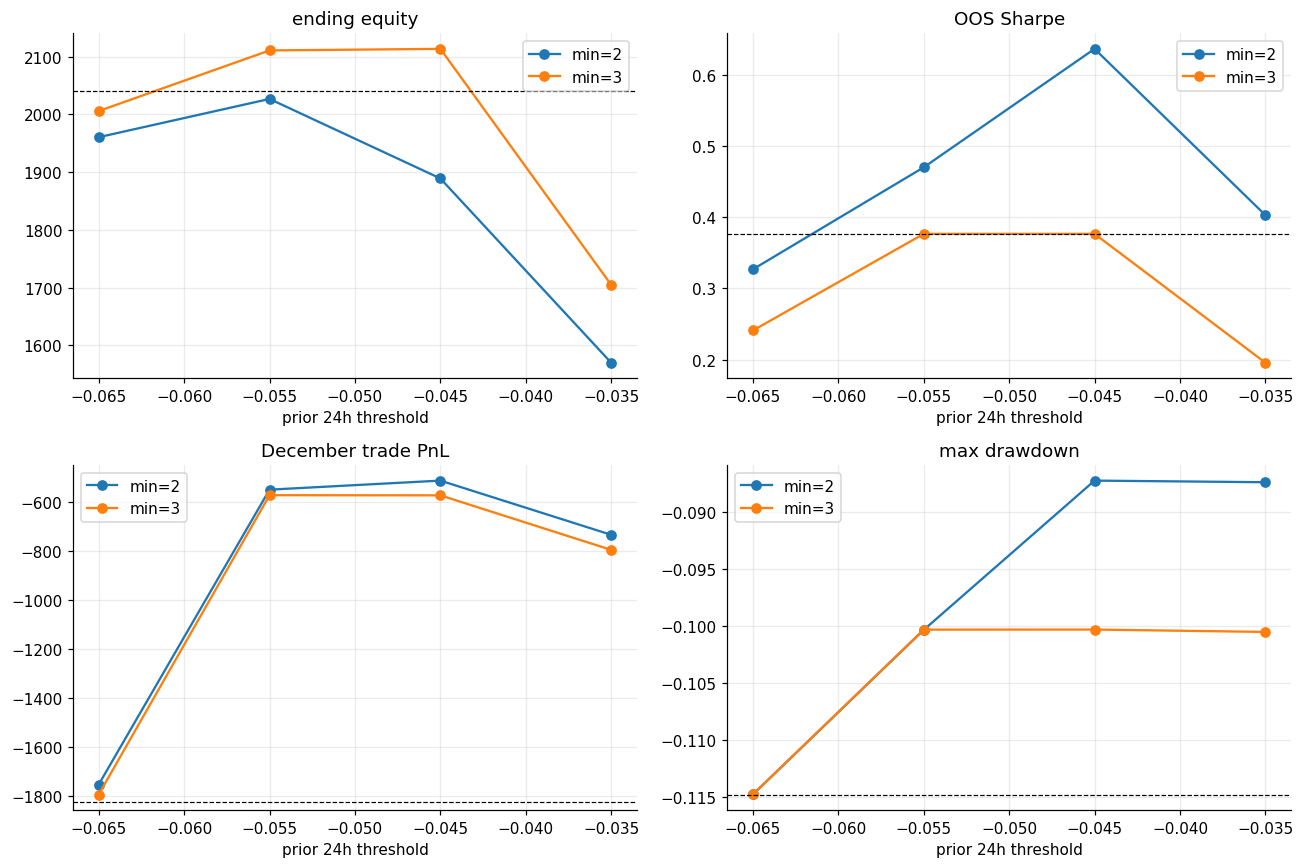

In [8]:
grid_only = summary.drop(index="champion")
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for min_cluster, sub in grid_only.groupby("short_cluster_min"):
    sub = sub.sort_values("short_cluster_prior_move")
    label = f"min={int(min_cluster)}"
    sub.plot(x="short_cluster_prior_move", y="end_equity", marker="o", label=label, ax=ax[0,0])
    sub.plot(x="short_cluster_prior_move", y="oos_sharpe", marker="o", label=label, ax=ax[0,1])
    sub.plot(x="short_cluster_prior_move", y="dec_pnl", marker="o", label=label, ax=ax[1,0])
    sub.plot(x="short_cluster_prior_move", y="max_dd", marker="o", label=label, ax=ax[1,1])
ax[0,0].axhline(champ["end_equity"], color="k", ls="--", lw=0.8)
ax[0,0].set_title("ending equity")
ax[0,1].axhline(champ["oos_sharpe"], color="k", ls="--", lw=0.8)
ax[0,1].set_title("OOS Sharpe")
ax[1,0].axhline(champ["dec_pnl"], color="k", ls="--", lw=0.8)
ax[1,0].set_title("December trade PnL")
ax[1,1].axhline(champ["max_dd"], color="k", ls="--", lw=0.8)
ax[1,1].set_title("max drawdown")
for axis in ax.ravel():
    axis.set_xlabel("prior 24h threshold")
show("07_cluster_guard_grid_threshold_curves")

,champion,cluster_m3_0.045,cluster_m3_0.055,cluster_m2_0.055,cluster_m2_0.045
entry_day,,,,,
2025-12-01 00:00:00+00:00,-1272.331597,0.000000,0.000000,0.000000,0.000000
2025-12-02 00:00:00+00:00,422.461198,437.457163,436.928925,419.668136,391.401205
2025-12-03 00:00:00+00:00,-189.894584,-196.633501,-196.396063,-188.637476,-175.931716
2025-12-05 00:00:00+00:00,-72.476999,-75.049039,-74.958416,-71.997198,-67.147796
2025-12-07 00:00:00+00:00,435.578645,451.036318,450.491683,432.695100,403.550732
2025-12-09 00:00:00+00:00,-681.011502,-705.179016,-704.327499,-676.503183,-630.937015
2025-12-12 00:00:00+00:00,431.870039,447.196102,446.656104,429.011045,400.114818
2025-12-15 00:00:00+00:00,408.326882,422.817454,422.306893,405.623745,378.302780
2025-12-17 00:00:00+00:00,74.098628,76.728216,76.635565,73.608093,68.650187


[saved] notebooks\volume_weighted_breakout\_out\07_cluster_guard_grid_daily_pnl_top.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/07_cluster_guard_grid_daily_pnl_top.png')

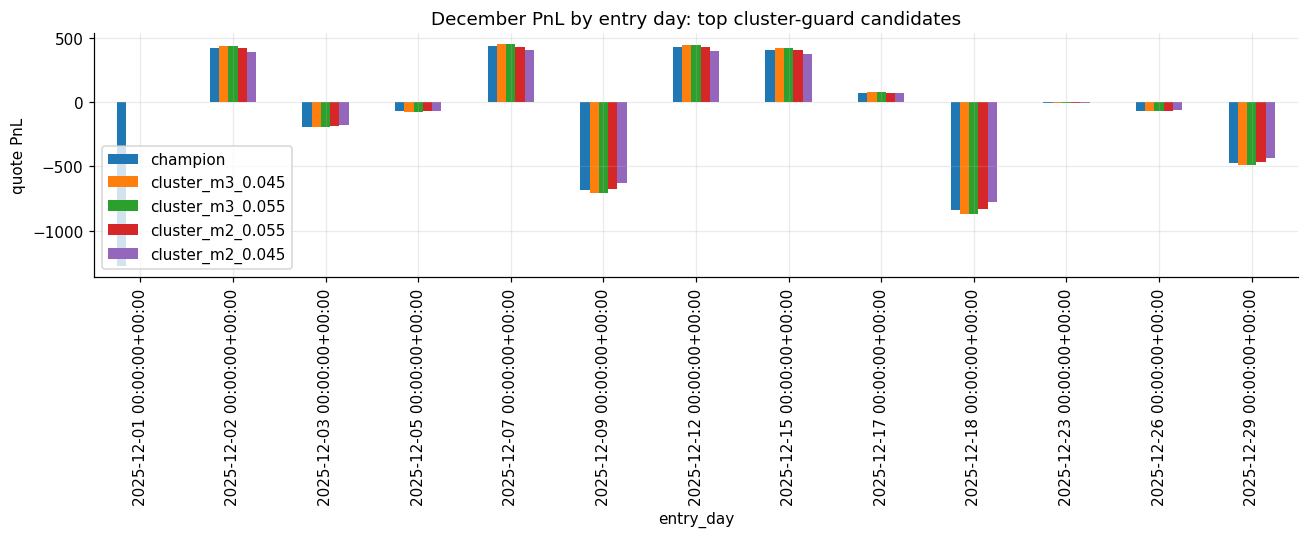

In [9]:
# Daily December damage for top compromise candidates.
top_names = list(ranked.drop(index="champion").sort_values("compromise_score", ascending=False).head(4).index)
daily_frames = []
for name in ["champion", *top_names]:
    res = results[name]
    tr = res["curves"]["trades"].copy()
    tr["entry_time"] = pd.to_datetime(tr["entry_time"], utc=True)
    dec = tr[(tr["entry_time"] >= dec_start) & (tr["entry_time"] < dec_end)].copy()
    dec["entry_day"] = dec["entry_time"].dt.floor("D")
    daily_frames.append(dec.groupby("entry_day")["pnl_quote"].sum().rename(name))
daily_cmp = pd.concat(daily_frames, axis=1).fillna(0.0)
display(daily_cmp)
daily_cmp.plot(kind="bar", figsize=(12, 5))
plt.title("December PnL by entry day: top cluster-guard candidates")
plt.ylabel("quote PnL")
show("07_cluster_guard_grid_daily_pnl_top")